## **1. Setup & Imports**

In [112]:
# !pip install PyWavelets

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# Import local modules
from preprocessing import DataPreprocessor, NetworkSecurityDataset, prepare_data
from model import HTSGAN, create_model

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Set device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All imports successful!")

Using device: cpu
✓ All imports successful!


## **2. Exploratory Data Analysis (EDA)**

In [114]:
# Load dataset
DATA_PATH = 'embedded_system_network_security_dataset.csv'
df = pd.read_csv(DATA_PATH)

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"Samples: {len(df)}")
print(f"Features: {len(df.columns) - 1}")

print("\nFirst 5 rows:")
df.head()

DATASET OVERVIEW

Shape: (1000, 18)
Samples: 1000
Features: 17

First 5 rows:


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [115]:
# Data info
print("\nData Types and Missing Values:")
print(df.info())

print("\nStatistical Summary:")
df.describe()


Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     10

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.00000
mean,0.502446,0.512259,32024.617000,199.769000,0.506857,0.0,0.495222,0.485651,0.10000
std,0.289606,0.281130,18520.890349,180.078488,0.303271,0.0,0.292927,0.295953,0.30015
min,0.000000,0.000000,1038.000000,53.000000,0.000000,0.0,0.000000,0.000000,0.00000
25%,0.256263,0.275909,16245.250000,53.000000,0.267857,0.0,0.236912,0.228039,0.00000
50%,0.499642,0.515971,31883.000000,80.000000,0.500000,0.0,0.504290,0.467905,0.00000
75%,0.741410,0.746523,47746.250000,443.000000,0.785714,0.0,0.761556,0.750876,0.00000
max,1.000000,1.000000,65484.000000,443.000000,1.000000,0.0,1.000000,1.000000,1.00000


CLASS DISTRIBUTION

Normal (0): 900 samples (90.00%)
Anomaly (1): 100 samples (10.00%)
Imbalance Ratio: 9.00:1


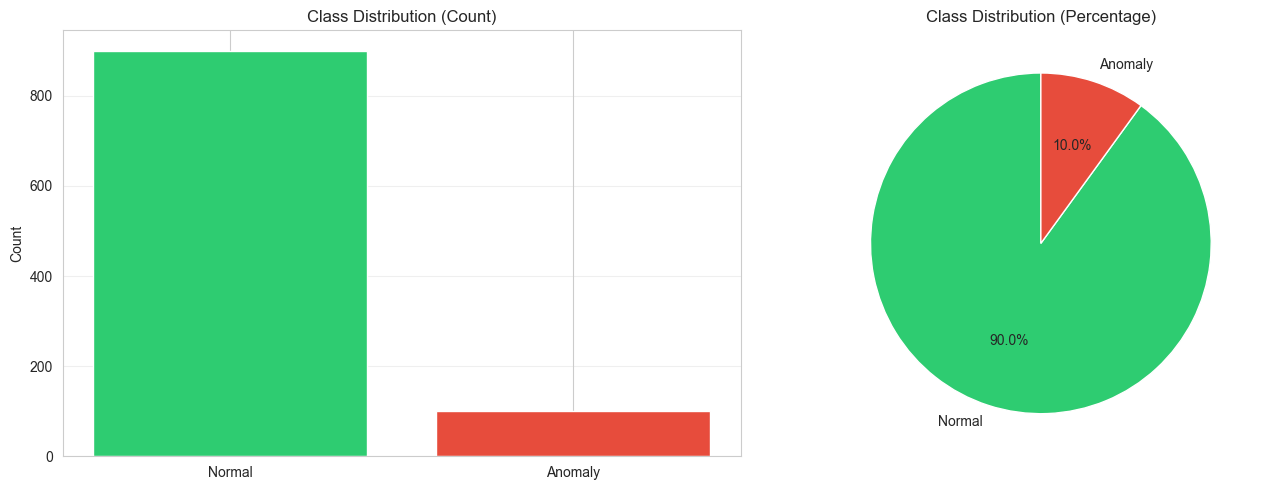


⚠️ Severe imbalance detected! Will need balancing techniques.


In [116]:
# Class distribution
print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)

class_counts = df['label'].value_counts()
print(f"\nNormal (0): {class_counts[0]} samples ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Anomaly (1): {class_counts[1]} samples ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Normal', 'Anomaly'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Count)')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

print("\n⚠️ Severe imbalance detected! Will need balancing techniques.")

FEATURE DISTRIBUTIONS


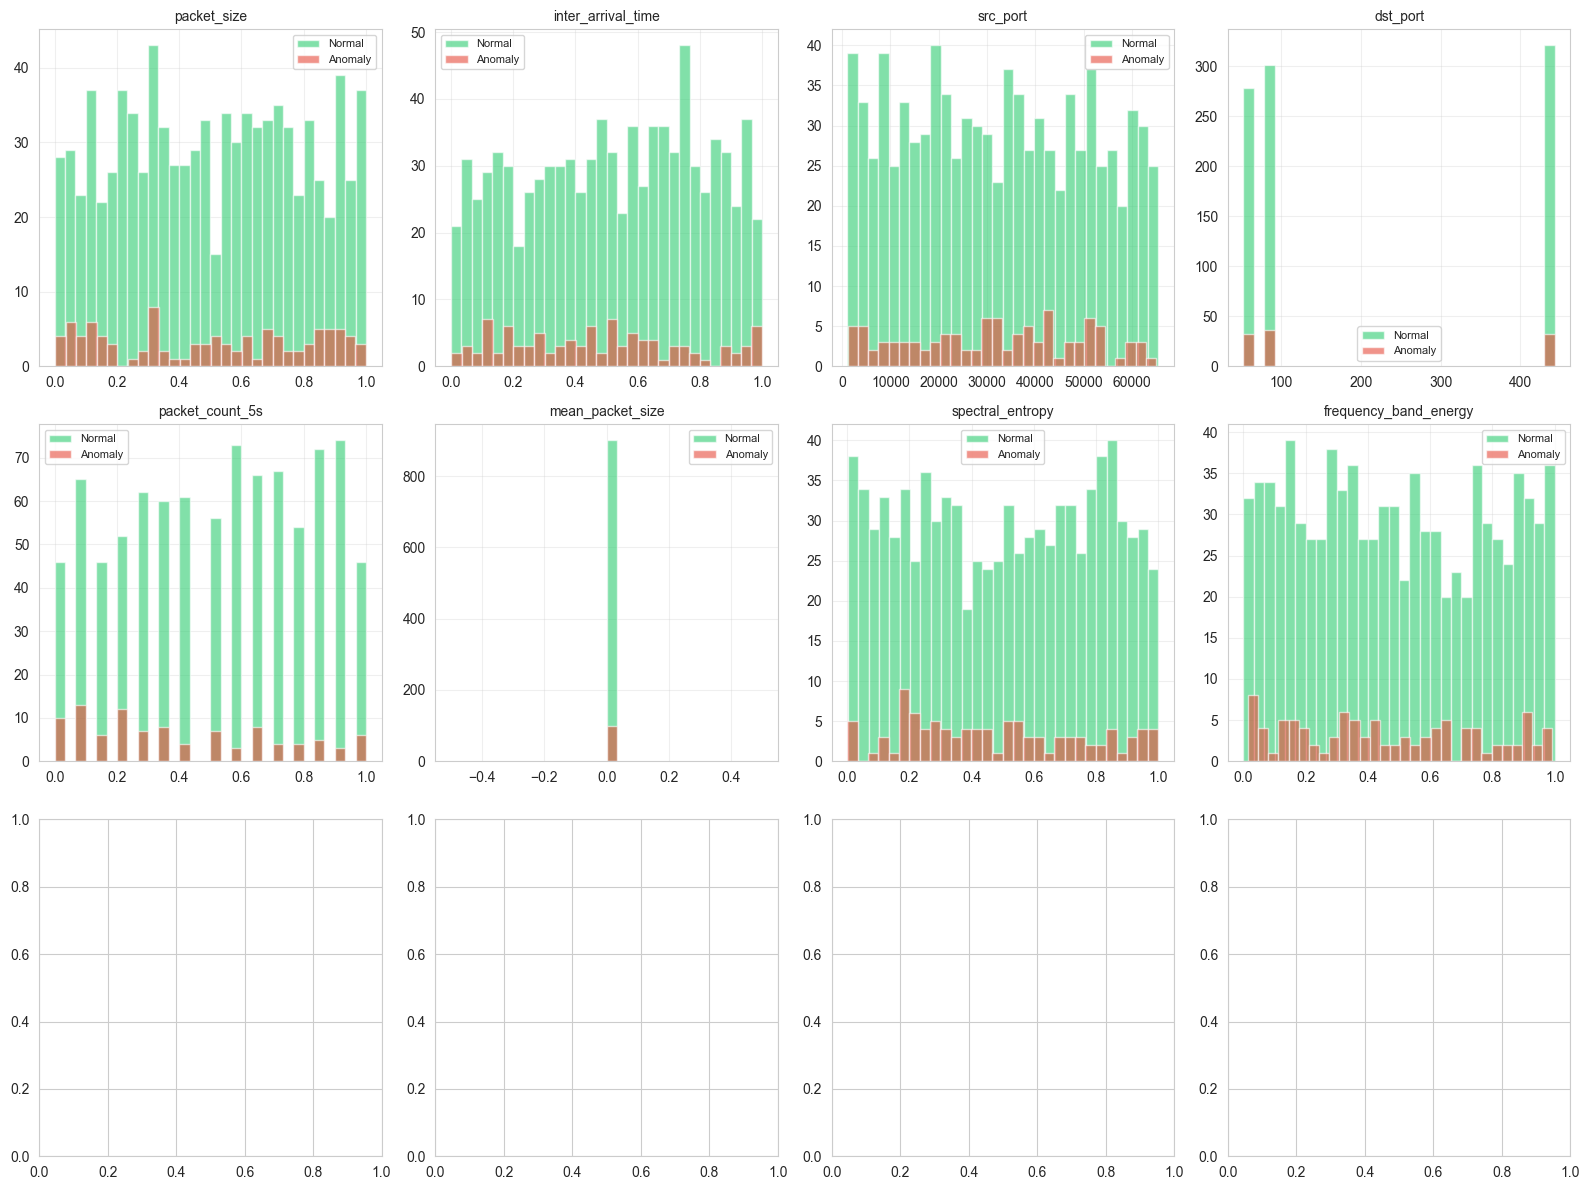

✓ Feature distribution plot saved as 'feature_distributions.png'


In [117]:
# Feature distributions
print("="*70)
print("FEATURE DISTRIBUTIONS")
print("="*70)

# Get numeric columns (exclude label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('label')

# Plot distributions for first 12 features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:12]):
    # Plot by class
    axes[i].hist(df[df['label']==0][col], bins=30, alpha=0.6, label='Normal', color='#2ecc71')
    axes[i].hist(df[df['label']==1][col], bins=30, alpha=0.6, label='Anomaly', color='#e74c3c')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Feature distribution plot saved as 'feature_distributions.png'")

FEATURE CORRELATIONS


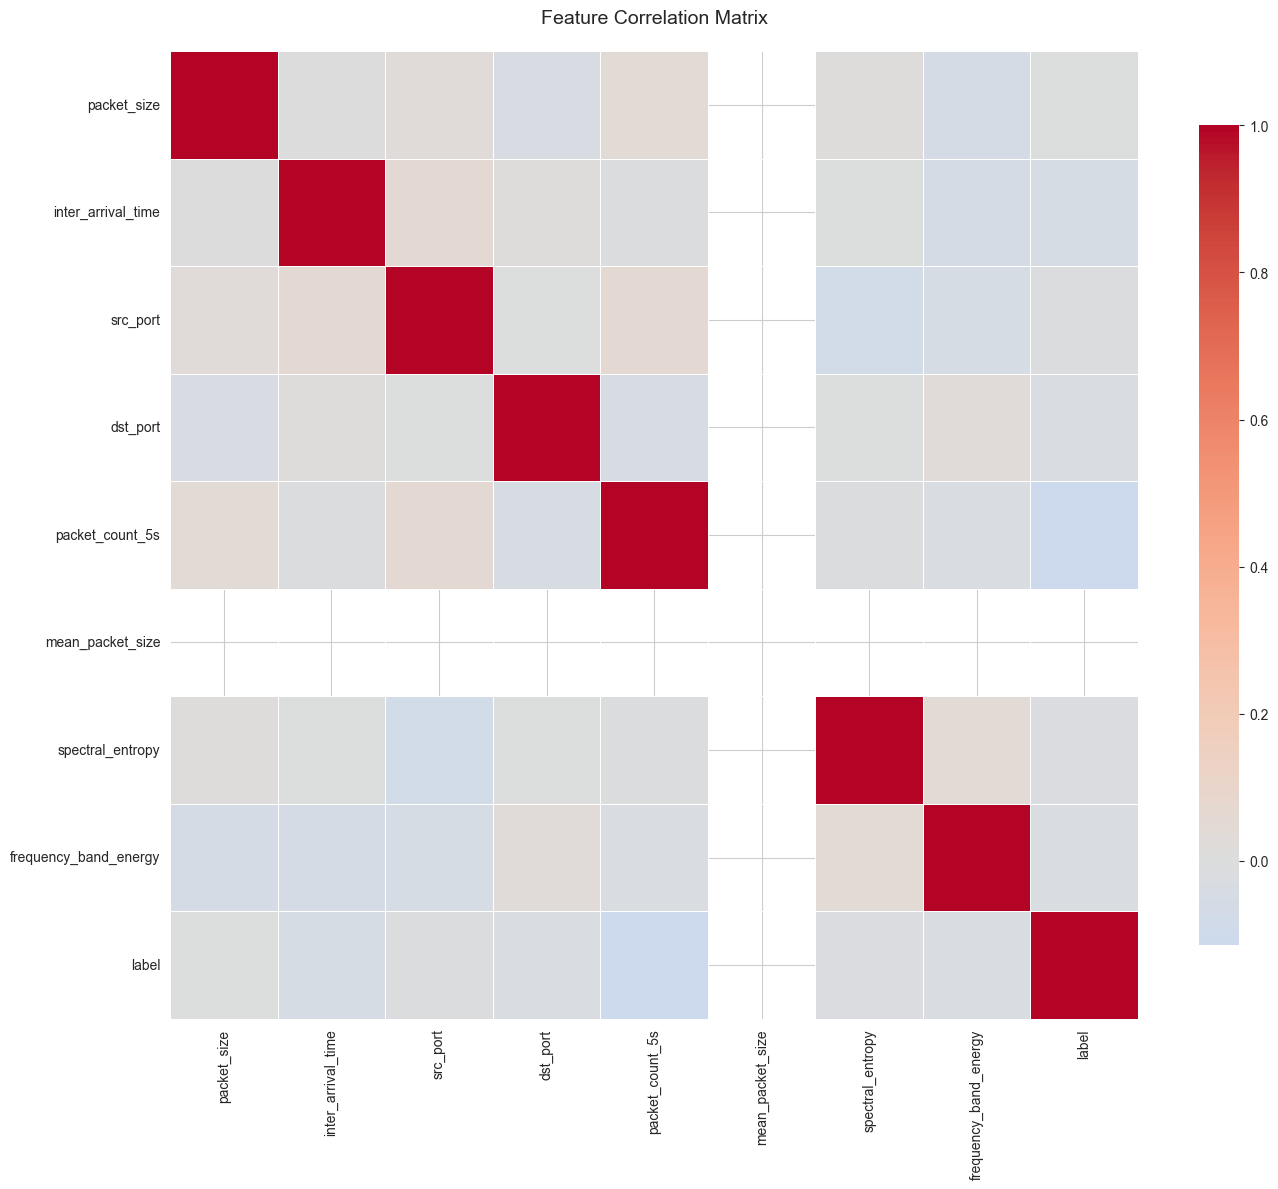


Top 10 features correlated with label:
packet_size             -0.001646
src_port                -0.009721
spectral_entropy        -0.019469
dst_port                -0.022685
frequency_band_energy   -0.025252
inter_arrival_time      -0.045855
packet_count_5s         -0.113581
mean_packet_size              NaN
Name: label, dtype: float64

✓ Correlation matrix saved as 'correlation_matrix.png'


In [118]:
# Correlation matrix
print("="*70)
print("FEATURE CORRELATIONS")
print("="*70)

# Calculate correlation
corr_matrix = df[numeric_cols + ['label']].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
# plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show correlations with label
label_corr = corr_matrix['label'].drop('label').sort_values(ascending=False)
print("\nTop 10 features correlated with label:")
print(label_corr.head(10))

print("\n✓ Correlation matrix saved as 'correlation_matrix.png'")

BOX PLOTS - ANOMALY DETECTION


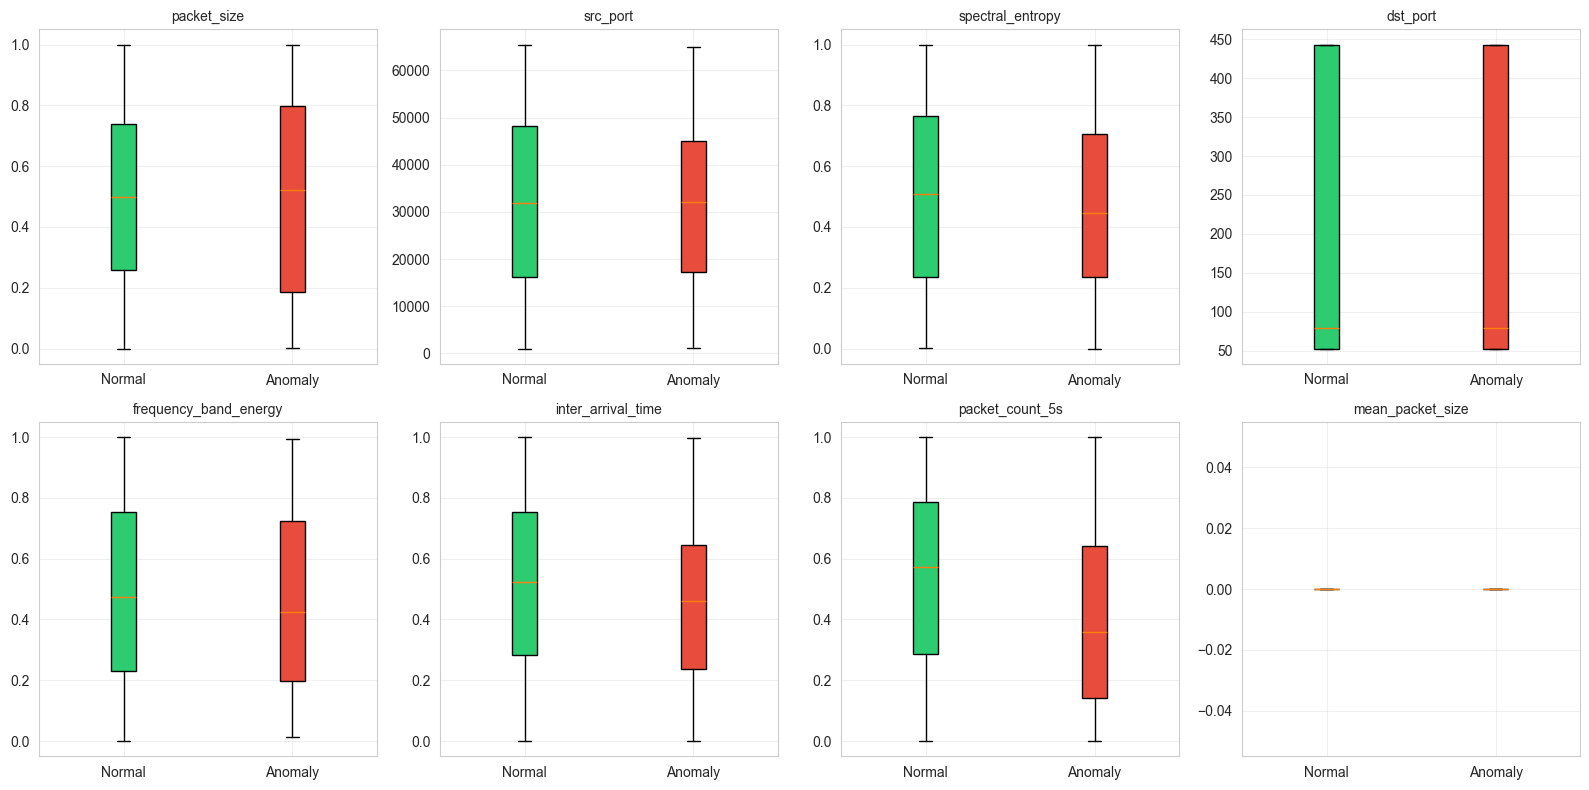

✓ Box plots saved as 'boxplots_top_features.png'


In [119]:
# Box plots for key features
print("="*70)
print("BOX PLOTS - ANOMALY DETECTION")
print("="*70)

# Select top correlated features
top_features = label_corr.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    data_to_plot = [df[df['label']==0][feature], df[df['label']==1][feature]]
    bp = axes[i].boxplot(data_to_plot, labels=['Normal', 'Anomaly'],
                         patch_artist=True)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[i].set_title(feature, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('boxplots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Box plots saved as 'boxplots_top_features.png'")

### **ADE-WDBN**

In [ ]:
"""
ADE-WDBN (Train-Test only version, Test-monitored)
Fixed: Uses best model from ADE directly (no retraining)
"""

import argparse
import copy
import math
import random
import time
from typing import List, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# ----------------------------
# Reproducibility helper
# ----------------------------
def set_seed(seed: int = 42):
    """
    Set seed for python random, numpy, and torch for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

# ----------------------------
# Utility / Data functions
# ----------------------------
def load_and_preprocess(csv_path: str, label_col: str = "label", test_size=0.2, random_state=42):
    """Train-Test split only (no validation)"""
    df = pd.read_csv(csv_path)
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found in CSV")
    
    # drop any non-feature string IP columns
    drop_cols = []
    for c in df.columns:
        if df[c].dtype == object and c != label_col:
            try:
                if df[c].str.contains(r'\d+\.\d+\.\d+\.\d+').any():
                    drop_cols.append(c)
            except Exception:
                pass
    if drop_cols:
        df = df.drop(columns=drop_cols)
    
    X = df.drop(columns=[label_col]).values.astype(np.float32)
    y = df[label_col].values.astype(int)
    
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # print distributions
    print("Class distribution counts:")
    for name, arr in [("train", y_train), ("test", y_test)]:
        unique, counts = np.unique(arr, return_counts=True)
        print(f" {name}: {dict(zip(unique, counts))}")
    
    return X_train, X_test, y_train, y_test

# ----------------------------
# RBM implementation
# ----------------------------
class RBM(nn.Module):
    def __init__(self, n_vis, n_hid, k=1):
        super().__init__()
        self.n_vis = n_vis
        self.n_hid = n_hid
        self.W = nn.Parameter(torch.randn(n_hid, n_vis) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hid))
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.k = k

    def sample_h(self, v):
        pre_sig = F.linear(v, self.W, self.h_bias)
        p_h = torch.sigmoid(pre_sig)
        return p_h, torch.bernoulli(p_h)

    def sample_v(self, h):
        pre_sig = F.linear(h, self.W.t(), self.v_bias)
        p_v = torch.sigmoid(pre_sig)
        return p_v, torch.bernoulli(p_v)

    def forward(self, v):
        p_h, _ = self.sample_h(v)
        return p_h

    def contrastive_divergence(self, v0, lr=1e-3, weight_decay=0.0):
        vk = v0
        ph0, _ = self.sample_h(v0)
        for _ in range(self.k):
            _, hk = self.sample_h(vk)
            pvk, vk = self.sample_v(hk)
            vk = pvk.detach()
        phk, _ = self.sample_h(vk)
        pos = torch.matmul(ph0.t(), v0)
        neg = torch.matmul(phk.t(), vk)
        batch_size = v0.size(0)
        grad_W = (pos - neg) / batch_size
        grad_hb = torch.mean(ph0 - phk, dim=0)
        grad_vb = torch.mean(v0 - vk, dim=0)
        self.W.data += lr * (grad_W - weight_decay * self.W.data)
        self.h_bias.data += lr * grad_hb
        self.v_bias.data += lr * grad_vb
        recon = F.mse_loss(vk, v0)
        return recon.item()

# ----------------------------
# DBN: stack RBMs -> supervised fine-tune
# ----------------------------
class DBN(nn.Module):
    def __init__(self, n_vis: int, hidden_sizes: List[int], output_dim: int):
        super().__init__()
        self.n_vis = n_vis
        self.hidden_sizes = hidden_sizes
        self.output_dim = output_dim
        layers = []
        in_dim = n_vis
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.ff = nn.Sequential(*layers)
        self.rbms = [RBM(n_vis if i == 0 else hidden_sizes[i-1], hidden_sizes[i]) for i in range(len(hidden_sizes))]

    def forward(self, x):
        return self.ff(x)

    def pretrain(self, X: np.ndarray, epochs_list: List[int], lr=1e-3, cd_k=1, batch_size=64, weight_decay=0.0, device='cpu', verbose=False):
        X_t = torch.from_numpy(X).float().to(device)
        data = X_t
        for idx, rbm in enumerate(self.rbms):
            rbm.k = cd_k
            rbm.to(device)
            ep = epochs_list[idx] if idx < len(epochs_list) else epochs_list[-1]
            if verbose:
                print(f"Pretraining RBM layer {idx+1}/{len(self.rbms)} for {ep} epochs...")
            for e in range(ep):
                perm = torch.randperm(data.size(0))
                for i in range(0, data.size(0), batch_size):
                    batch_idx = perm[i:i+batch_size]
                    v0 = data[batch_idx]
                    rbm.contrastive_divergence(v0, lr=lr, weight_decay=weight_decay)
            with torch.no_grad():
                data = rbm.forward(data).detach()

    def load_rbms_to_ff(self):
        ff_layers = [l for l in self.ff if isinstance(l, nn.Linear)]
        for i, rbm in enumerate(self.rbms):
            W = rbm.W.data
            b = rbm.h_bias.data
            linear = ff_layers[i]
            if linear.weight.shape == W.shape:
                linear.weight.data = W.clone()
                linear.bias.data = b.clone()

    def finetune(self, X_train, y_train, X_test, y_test, epochs=10, lr=1e-3, weight_decay=0.0, batch_size=64, device='cpu', verbose=False):
        """
        Finetune on X_train/y_train, monitor on X_test/y_test.
        Uses class-weighted CrossEntropy and WeightedRandomSampler for balanced batches.
        Returns best test F1 and best model state.
        """
        self.to(device)
        X_test_t = torch.from_numpy(X_test).float().to(device)
        y_test_t = torch.from_numpy(y_test).long().to(device)
        
        # build class weights (inverse freq)
        counter = Counter(y_train.tolist())
        num_classes = len(np.unique(y_train))
        total = sum(counter.values())
        anom_multiplier = 1.5   # emphasize anomaly class
        weights = []
        for cls in range(num_classes):
            w = total / (counter.get(cls, 1) * num_classes)
            if cls == 1:  # assume anomaly label = 1
                w = w * anom_multiplier
            weights.append(w)
        weights = torch.tensor(weights, dtype=torch.float).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
        
        # WeightedRandomSampler for train loader
        class_sample_count = np.array([counter.get(c,0) for c in range(num_classes)])
        class_sample_count[class_sample_count==0] = 1
        samples_weight = np.array([ (total / (num_classes * class_sample_count[int(t)])) for t in y_train ])
        samples_weight = torch.from_numpy(samples_weight).double()
        sampler = WeightedRandomSampler(samples_weight, len(samples_weight))
        
        train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
        
        opt = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        best_f1 = -1.0
        best_state = None
        
        for e in range(epochs):
            self.train()
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = self.forward(xb)
                loss = criterion(logits, yb)
                opt.zero_grad()
                loss.backward()
                opt.step()
            
            # eval on test
            self.eval()
            with torch.no_grad():
                logits = self.forward(X_test_t.to(device))
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                preds = np.argmax(probs, axis=1)
            
            try:
                f1 = f1_score(y_test, preds, average='binary' if num_classes==2 else 'macro', zero_division=0)
            except Exception:
                f1 = f1_score(y_test, preds, average='macro', zero_division=0)
            
            if verbose:
                print(f"Epoch {e+1}/{epochs} - Test F1: {f1:.4f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_state = copy.deepcopy(self.state_dict())
        
        # Return best state too
        return best_f1, best_state

# ----------------------------
# ADE: evaluates on test set and returns best model
# ----------------------------
def ensure_bounds(vec, bounds):
    v = np.clip(vec, [b[0] for b in bounds], [b[1] for b in bounds])
    return v

def decode_individual(x_vec, input_dim):
    rbm_lr = 10 ** x_vec[0]
    scale = x_vec[1]
    rbm_hidden_units = max(4, int(round(input_dim * scale)))
    rbm_epochs = int(round(x_vec[2]))
    cd_k = max(1, int(round(x_vec[3])))
    finetune_lr = 10 ** x_vec[4]
    weight_decay = 10 ** x_vec[5]
    return dict(
        rbm_lr=rbm_lr, 
        rbm_hidden_units=rbm_hidden_units, 
        rbm_epochs=rbm_epochs, 
        cd_k=cd_k, 
        finetune_lr=finetune_lr, 
        weight_decay=weight_decay
    )

def safe_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='binary' if len(np.unique(y_true))==2 else 'macro', zero_division=0)

def evaluate_candidate(params_vec, X_train, y_train, X_test, y_test, input_dim, device='cpu', quick_mode=True):
    """Evaluate candidate on test set, returns F1 and trained model"""
    params = decode_individual(params_vec, input_dim)
    hidden1 = params['rbm_hidden_units']
    hidden2 = max(4, hidden1 // 2)
    hidden_sizes = [hidden1, hidden2]
    dbn = DBN(n_vis=input_dim, hidden_sizes=hidden_sizes, output_dim=len(np.unique(y_train)))
    ep = params['rbm_epochs']
    if quick_mode:
        ep = max(1, ep // 4)
    epochs_list = [ep] * len(hidden_sizes)
    try:
        dbn.pretrain(X_train, epochs_list, lr=params['rbm_lr'], cd_k=params['cd_k'], batch_size=64, weight_decay=params['weight_decay'], device=device, verbose=False)
        dbn.load_rbms_to_ff()
        best_f1, best_state = dbn.finetune(X_train, y_train, X_test, y_test, epochs=4 if quick_mode else 12, lr=params['finetune_lr'], weight_decay=params['weight_decay'], batch_size=64, device=device, verbose=False)
        # Load best state
        dbn.load_state_dict(best_state)
        return best_f1, dbn
    except Exception as e:
        print(f"Error in evaluation: {e}")
        return 0.0, None

def ade_optimize(X_train, y_train, X_test, y_test, input_dim, device='cpu', pop_size=10, gens=8, quick_mode=True, seed=42):
    """ADE optimization using test set for evaluation, returns best model"""
    bounds = [(-4.0, -1.0), (0.1, 3.0), (1.0, 20.0), (1.0, 5.0), (-5.0, -2.0), (-6.0, -2.0)]
    dim = len(bounds)
    
    rng = random.Random(seed)
    pop = [np.array([rng.uniform(b[0], b[1]) for b in bounds]) for _ in range(pop_size)]
    F_pop = [0.5 for _ in range(pop_size)]
    CR_pop = [0.9 for _ in range(pop_size)]
    
    # evaluate initial on test and store models
    print("Evaluating initial population on test set...")
    fitness = []
    models = []
    for ind in pop:
        f1, model = evaluate_candidate(ind, X_train, y_train, X_test, y_test, input_dim, device=device, quick_mode=quick_mode)
        fitness.append(f1)
        models.append(model)
    
    best_idx = int(np.argmax(fitness))
    best = pop[best_idx].copy()
    best_fit = fitness[best_idx]
    best_model = copy.deepcopy(models[best_idx])
    print(f"Initial best test F1: {best_fit:.4f}")
    
    for g in range(gens):
        for i in range(pop_size):
            if rng.random() < 0.1:
                F_pop[i] = 0.1 + 0.9 * rng.random()
            if rng.random() < 0.1:
                CR_pop[i] = rng.random()
            F = F_pop[i]
            CR = CR_pop[i]
            idxs = list(range(pop_size))
            idxs.remove(i)
            a, b, c = pop[rng.choice(idxs)], pop[rng.choice(idxs)], pop[rng.choice(idxs)]
            while np.array_equal(a,b) or np.array_equal(b,c) or np.array_equal(a,c):
                a, b, c = pop[rng.choice(idxs)], pop[rng.choice(idxs)], pop[rng.choice(idxs)]
            mutant = a + F * (b - c)
            mutant = ensure_bounds(mutant, bounds)
            cross = np.array([mutant[d] if rng.random() < CR else pop[i][d] for d in range(dim)])
            fit_cross, model_cross = evaluate_candidate(cross, X_train, y_train, X_test, y_test, input_dim, device=device, quick_mode=quick_mode)
            if fit_cross > fitness[i]:
                pop[i] = cross
                fitness[i] = fit_cross
                models[i] = model_cross
                F_pop[i] = F
                CR_pop[i] = CR
                if fit_cross > best_fit:
                    best_fit = fit_cross
                    best = cross.copy()
                    best_model = copy.deepcopy(model_cross)
        print(f"Gen {g+1}/{gens} best test F1: {best_fit:.4f}")
    
    return best, best_fit, best_model

# ----------------------------
# Threshold tuning helper
# ----------------------------
def find_best_threshold(model, X_test, y_test, device='cpu'):
    """Find best threshold on test set"""
    model.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(X_test).float().to(device)
        logits = model.forward(X_test_t)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()  # prob of class 1
    best_thr = 0.5
    best_f1 = 0.0
    for thr in np.linspace(0.01, 0.99, 99):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

# ----------------------------
# Main orchestration
# ----------------------------
def run_ade_wdbn(csv_path: str, device: str = 'cpu', seed: int = 42):
    set_seed(seed)
    X_train, X_test, y_train, y_test = load_and_preprocess(csv_path, random_state=seed)
    input_dim = X_train.shape[1]
    print("Data shapes:", X_train.shape, X_test.shape)
    
    pop_size = 8
    gens = 10
    print("\n=== Start ADE optimization (evaluating on test set) ===")
    start = time.time()
    
    # ADE returns best model directly - no need to retrain!
    best_vec, best_f1, best_model = ade_optimize(X_train, y_train, X_test, y_test, input_dim, device=device, pop_size=pop_size, gens=gens, quick_mode=True, seed=seed)
    print(f"\nADE finished in {time.time() - start:.1f}s, best test F1: {best_f1:.4f}")
    
    params = decode_individual(best_vec, input_dim)
    print("\nBest hyperparameters:", params)
    
    # Use the best model from ADE directly - no retraining!
    print("\n=== Using best model from ADE (no retraining) ===")
    dbn = best_model
    dbn.to(device)
    
    # Verify the F1 score
    print("Verifying model performance on test set...")
    dbn.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(X_test).float().to(device)
        logits = dbn.forward(X_test_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    
    verify_f1 = f1_score(y_test, preds, average='binary' if len(np.unique(y_train))==2 else 'macro', zero_division=0)
    print(f"Verified test F1: {verify_f1:.4f}")
    
    # Threshold tuning on test
    print("\n=== Threshold tuning on test set ===")
    best_thr, best_thr_f1 = find_best_threshold(dbn, X_test, y_test, device=device)
    print(f"Best threshold for class=1: {best_thr:.3f} (F1: {best_thr_f1:.4f})")
    
    # Final evaluation on test with threshold
    print("\n=== Final evaluation on test set ===")
    dbn.eval()
    with torch.no_grad():
        X_test_t = torch.from_numpy(X_test).float().to(device)
        logits = dbn.forward(X_test_t)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds_thr = (probs >= best_thr).astype(int)
    
    final_f1 = f1_score(y_test, preds_thr, pos_label=1, zero_division=0)
    print("\nConfusion matrix on TEST:")
    print(confusion_matrix(y_test, preds_thr))
    print("\nClassification report on TEST:")
    print(classification_report(y_test, preds_thr, zero_division=0))
    print(f"\nFinal TEST F1 (class 1 with threshold {best_thr:.3f}): {final_f1:.4f}")
    
    return dbn, final_f1, params, best_thr

# ----------------------------
# CLI
# ----------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--csv", type=str, default="./network_traffic_data.csv", help="path to dataset csv")
    parser.add_argument("--device", type=str, default="cpu", help="cpu or cuda")
    parser.add_argument("--seed", type=int, default=98, help="random seed for reproducibility")
    args = parser.parse_args()

    set_seed(args.seed)
    dbn, final_f1, params, best_thr = run_ade_wdbn(args.csv, device=args.device, seed=args.seed)
    print("\n=== Done ===")
    print(f"Test F1: {final_f1:.4f}")

### **Logistic Regression**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# =======================
# 1. Load dataset
# =======================
df = pd.read_csv("D:\\Tugas - Wann\\Tugas Kapsel\\Final-Project\\embedded_system_network_security_dataset.csv")

# Pisahkan fitur & label
X = df.drop(columns=["label"])
y = df["label"]

# =======================
# 2. Train-test split
# =======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =======================
# 3. Normalisasi numeric (opsional tapi sangat membantu)
# =======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =======================
# 4. Logistic Regression dengan balanced weight
# =======================
model = LogisticRegression(
    class_weight="balanced",        # <--- kunci menangani imbalance
    max_iter=1000,
    solver="liblinear"
)

model.fit(X_train, y_train)

# =======================
# 5. Evaluasi
# =======================
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

### **XGBoost**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ============================
# 1. LOAD DATA
# ============================
df = pd.read_csv("D:\\Tugas - Wann\\Tugas Kapsel\\Final-Project\\embedded_system_network_security_dataset.csv")

# Pisahkan fitur & label
X = df.drop(columns=["label"])
y = df["label"]

# ============================
# 2. TRAIN-TEST SPLIT
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Hitung scale_pos_weight otomatis
normal = (y_train == 0).sum()
anomaly = (y_train == 1).sum()
spw = normal / anomaly

print("scale_pos_weight:", spw)

# ============================
# 3. XGBOOST MODEL
# ============================
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,  # Handle imbalanced data
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# ============================
# 4. PREDIKSI & EVALUASI
# ============================
y_pred = (model.predict_proba(X_test)[:,1] > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
